#SOW ISMAEL

## Projet de master 2 – Apprentissage profond avancé


## **Introduction**
Dans le cadre de ce projet, l’objectif est d’explorer les modèles avancés de vision par ordinateur, tels que les réseaux de neurones convolutifs (CNN) et les modèles basés sur le transfert d’apprentissage, en les adaptant à un jeu de données sélectionné. L’approche suivie s’appuie sur des architectures populaires comme DenseNet et MobileNet, reconnues pour leur performance et leur efficacité computationnelle, tout en tenant compte des améliorations récentes à l’état de l’art. De plus, des réseaux convolutifs classiques comme VGG16 et ResNet, étudiés au cours, servent de base pour l'intégration des méthodes modernes

## Importation des librairies

In [ ]:
import os
import pickle
import time
import zipfile
import cv2
import gdown
import numpy as np
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import shutil

In [ ]:
# Définir une variable d'environnement pour permettre la croissance dynamique de la mémoire GPU
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

# Vérification et configuration du GPU
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"GPU disponible : {gpus[0].name}")
    try:
        # Configurer la croissance de la mémoire GPU pour éviter une allocation complète
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Configuration du GPU terminée.")
    except RuntimeError as e:
        print(f"Erreur lors de la configuration du GPU : {e}")
else:
    print("Aucun GPU détecté. Utilisation du CPU.")


GPU disponible : /physical_device:GPU:0
Configuration du GPU terminée.


## Utulisation d'un pourcentage des données

In [ ]:
# Répertoires source contenant toutes les images
train_dir = "/content/drive/MyDrive/APA/Dataset_Split/train"
val_dir = "/content/drive/MyDrive/APA/Dataset_Split/val"
test_dir = "/content/drive/MyDrive/APA/Dataset_Split/test"

# Répertoires temporaires pour le sous-échantillon
temp_train_dir = "/content/drive/MyDrive/APA/temp/train"
temp_val_dir = "/content/drive/MyDrive/APA/temp/val"
temp_test_dir = "/content/drive/MyDrive/APA/temp/test"

# Pourcentage à utiliser pour les sous-échantillons
subset_percentage = 1.0  # Utilisation final de  100% des données pour train/val/test

def create_subset(source_dir, target_dir, subset_percentage):
    """Création d'un sous-échantillon pour les données"""
    if os.path.exists(target_dir):
        print(f"Subset already exists at {target_dir}. Skipping creation.")
        return

    print(f"Creating subset at {target_dir}...")
    os.makedirs(target_dir, exist_ok=True)

    for class_name in os.listdir(source_dir):
        class_dir = os.path.join(source_dir, class_name)
        if os.path.isdir(class_dir):
            # Créez les répertoires de classes dans le répertoire temporaire
            target_class_dir = os.path.join(target_dir, class_name)
            os.makedirs(target_class_dir, exist_ok=True)

            # Liste des fichiers dans la classe actuelle
            files = os.listdir(class_dir)
            subset_count = int(len(files) * subset_percentage)
            for file in files[:subset_count]:
                shutil.copy(os.path.join(class_dir, file), os.path.join(target_class_dir, file))
    print(f"Subset created at {target_dir}.")

# Vérification et création des sous-échantillons pour l'entraînement, validation et test
create_subset(train_dir, temp_train_dir, subset_percentage)
create_subset(val_dir, temp_val_dir, subset_percentage)
create_subset(test_dir, temp_test_dir, subset_percentage)

# Chargement des données réduites
datagen = ImageDataGenerator(rescale=1./255)

train_data_subset = datagen.flow_from_directory(
    temp_train_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

val_data_subset = datagen.flow_from_directory(
    temp_val_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

test_data_subset = datagen.flow_from_directory(
    temp_test_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Vérifiez le nombre de données chargées
print(f"Training data subset: {train_data_subset.samples} samples")
print(f"Validation data subset: {val_data_subset.samples} samples")
print(f"Test data subset: {test_data_subset.samples} samples")


Subset already exists at /content/drive/MyDrive/APA/temp/train. Skipping creation.
Subset already exists at /content/drive/MyDrive/APA/temp/val. Skipping creation.
Subset already exists at /content/drive/MyDrive/APA/temp/test. Skipping creation.
Found 16277 images belonging to 2 classes.
Found 2034 images belonging to 2 classes.
Found 2036 images belonging to 2 classes.
Training data subset: 16277 samples
Validation data subset: 2034 samples
Test data subset: 2036 samples


## Visualiser quelques donnees

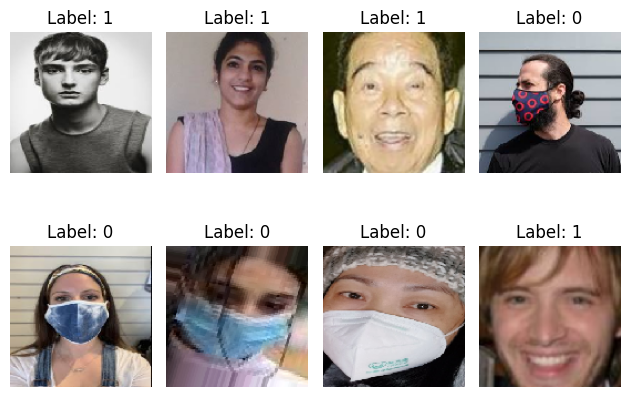

In [ ]:
# Récupérer un lot d'images et d'étiquettes
images, labels = next(train_data_subset)

# Afficher les premières images
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i])
    plt.title(f"Label: {np.argmax(labels[i])}")
    plt.axis('off')
plt.tight_layout()
plt.show()


Nombre total d'images dans l'ensemble d'entraînement :
Classe 'With_Mask': 8085
Classe 'Without_Mask': 8192

Nombre total d'images dans l'ensemble de validation :
Classe 'With_Mask': 1010
Classe 'Without_Mask': 1024

Nombre total d'images dans l'ensemble de test :
Classe 'With_Mask': 1012
Classe 'Without_Mask': 1024


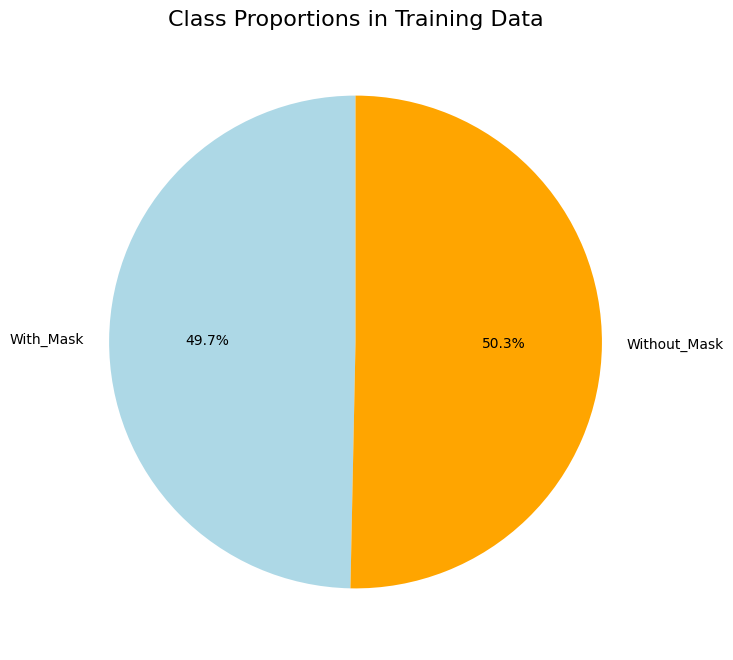

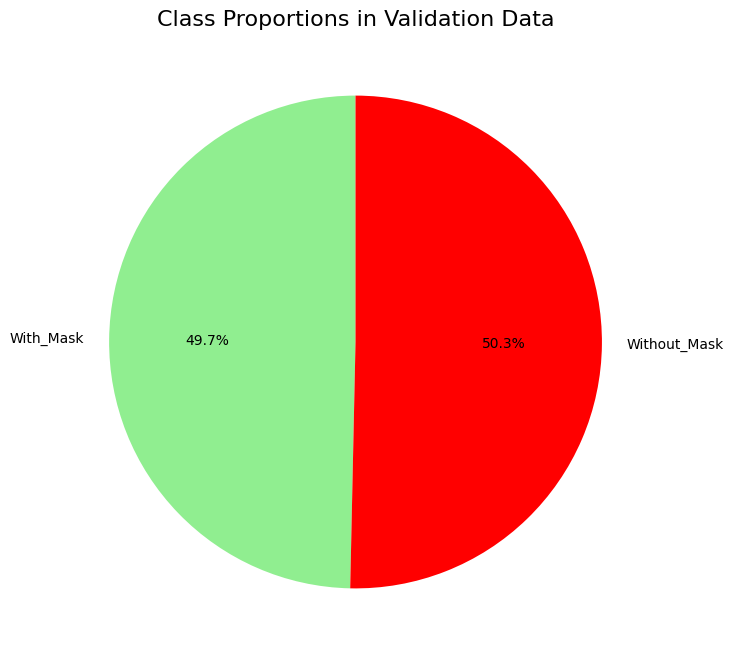

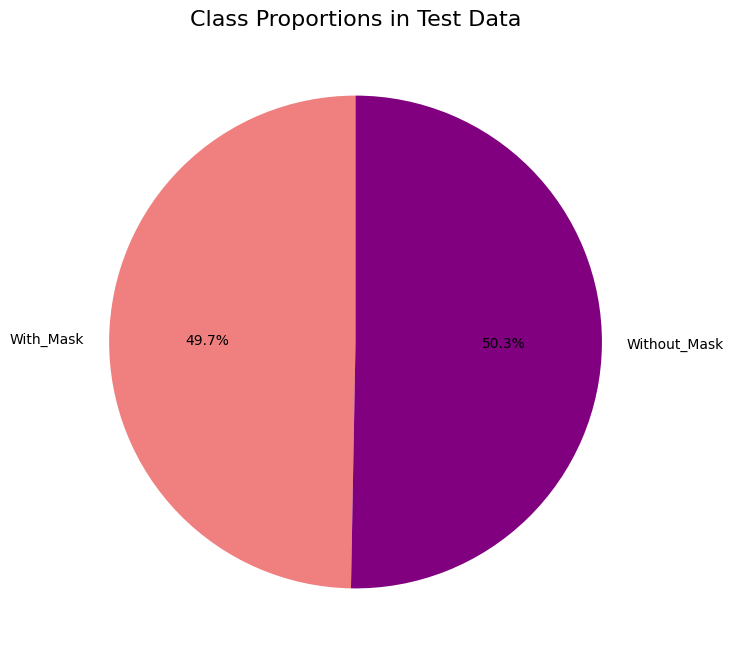

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Obtenir les étiquettes des classes pour les données d'entraînement, de validation et de test
train_labels = train_data_subset.classes
val_labels = val_data_subset.classes
test_labels = test_data_subset.classes

# Compter les occurrences de chaque classe dans les ensembles
train_class_counts = np.bincount(train_labels)
val_class_counts = np.bincount(val_labels)
test_class_counts = np.bincount(test_labels)
class_labels = list(train_data_subset.class_indices.keys())

# Afficher les totaux pour chaque classe
print("Nombre total d'images dans l'ensemble d'entraînement :")
for label, count in zip(class_labels, train_class_counts):
    print(f"Classe '{label}': {count}")

print("\nNombre total d'images dans l'ensemble de validation :")
for label, count in zip(class_labels, val_class_counts):
    print(f"Classe '{label}': {count}")

print("\nNombre total d'images dans l'ensemble de test :")
for label, count in zip(class_labels, test_class_counts):
    print(f"Classe '{label}': {count}")

# Visualisation pour l'ensemble d'entraînement
plt.figure(figsize=(8, 8))
plt.pie(train_class_counts, labels=class_labels, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'orange'])
plt.title('Class Proportions in Training Data', fontsize=16)
plt.show()

# Visualisation pour l'ensemble de validation
plt.figure(figsize=(8, 8))
plt.pie(val_class_counts, labels=class_labels, autopct='%1.1f%%', startangle=90, colors=['lightgreen', 'red'])
plt.title('Class Proportions in Validation Data', fontsize=16)
plt.show()

# Visualisation pour l'ensemble de test
plt.figure(figsize=(8, 8))
plt.pie(test_class_counts, labels=class_labels, autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'purple'])
plt.title('Class Proportions in Test Data', fontsize=16)
plt.show()


## Définition des variables globales

In [ ]:
# Configuration de l'entraînement
epochs = 35

# Dimensions des images en pixels
img_width, img_height = 128, 128

# Taille des lots
batch_size = 32

# Callback pour Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss',       # Surveiller la perte de validation
    patience=8,               # Nombre d'epochs sans amélioration avant arrêt
    restore_best_weights=True # Restaurer les meilleurs poids trouvés
)

# Callback pour réduire dynamiquement le learning rate
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',  # Surveiller la perte de validation
    factor=0.1,          # Réduction du learning rate par un facteur de 10
    patience=5,          # Nombre d'epochs sans amélioration avant réduction
    verbose=1            # Affichage des logs
)


## Définition des fonctions

In [ ]:
# Fonction pour afficher des images avec leurs labels
def display_images(images, labels, title):
    plt.figure(figsize=(12, 6))
    plt.suptitle(title, fontsize=14)
    for i in range(len(images)):
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[i])
        plt.title(f'Label: {labels[i]}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Fonction pour visualiser les métriques d'entraînement et de validation
def check_metrics(history, metric):
    train_metric = history[metric]
    val_metric = history[f'val_{metric}']

    epochs_range = range(1, len(train_metric) + 1)
    plt.plot(epochs_range, train_metric, label=f'Training {metric}', color='blue')
    plt.plot(epochs_range, val_metric, label=f'Validation {metric}', color='orange')
    plt.title(f'{metric.capitalize()} over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.show()


# Fonction pour afficher la matrice de confusion
def plot_confusion_matrix(model, data_generator):
    predictions = model.predict(data_generator)
    predicted_labels = np.argmax(predictions, axis=1)
    true_labels = data_generator.classes

    # Matrice de confusion
    cm = confusion_matrix(true_labels, predicted_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()

# Fonction pour mesurer le temps d'inférence sur un epoch
def measure_epoch_time(model, data_generator):
    start_time = time.time()
    model.predict(data_generator)
    end_time = time.time()
    return end_time - start_time

# Fonction pour visualiser le nombre de paramètres des modèles
def plot_model_parameters(models):
    param_counts = [model_info['model'].count_params() for model_info in models.values()]
    model_names = list(models.keys())

    plt.figure(figsize=(10, 6))
    plt.bar(model_names, param_counts, color='purple')
    plt.xlabel('Models')
    plt.ylabel('Number of Parameters')
    plt.title('Number of Parameters in Each Model')
    plt.xticks(rotation=45)
    plt.show()

# Fonction pour comparer les matrices de confusion de plusieurs modèles
def compare_confusion_matrices(models, data_generator):
    for model in models:
        predictions = model.predict(data_generator)
        predicted_labels = np.argmax(predictions, axis=1)
        true_labels = data_generator.classes

        cm = confusion_matrix(true_labels, predicted_labels)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title(f'Confusion Matrix for {model.name}')
        plt.xlabel('Predicted Labels')
        plt.ylabel('True Labels')
        plt.show()

# Fonction pour comparer la précision d'entraînement et de validation (groupée)
def compare_training_and_validation_accuracy_grouped(models, group='cnn'):
    plt.figure(figsize=(10, 6))

    for model_name, model_info in models.items():
        history = model_info['history']
        if group in model_name and history is not None:
            train_accuracy = history['accuracy']
            val_accuracy = history['val_accuracy']

            epochs = range(1, len(train_accuracy) + 1)
            plt.plot(epochs, train_accuracy, label=f'{model_name} - Training')
            plt.plot(epochs, val_accuracy, '--', label=f'{model_name} - Validation')

    plt.title(f'Training vs Validation Accuracy for {group.upper()} Models')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

# Définition des modèles

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.applications import VGG16, DenseNet121, MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, Conv2D, MaxPooling2D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import SGD, Adam

# Dictionnaire pour les modèles sans augmentation
models = {}

# Dictionnaire pour les modèles avec augmentation
models_augmented = {}

# Callback pour ajuster le learning rate
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=8, verbose=1)

# Fonction pour définir les modèles
def define_models(model_dict):
    # 1 Modèle CNN Simple
    simple_cnn_model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(2, activation='softmax')
    ])
    simple_cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model_dict['simple_cnn_model'] = {'model': simple_cnn_model, 'history': None, 'callbacks': [lr_scheduler]}

    # 2 Modèle CNN Complexe
    complicated_cnn_model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(2, activation='softmax')
    ])
    complicated_cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model_dict['complicated_cnn_model'] = {'model': complicated_cnn_model, 'history': None, 'callbacks': [lr_scheduler]}

    # 3 Transfer Learning avec VGG16
    vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
    vgg_base.trainable = False
    transfer_vgg_model = Sequential([
        vgg_base,
        Flatten(),
        Dense(256, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(0.5),
        Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(0.3),
        Dense(2, activation='softmax')
    ])
    transfer_vgg_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model_dict['transfer_vgg_model'] = {'model': transfer_vgg_model, 'history': None, 'callbacks': [lr_scheduler]}

    # 4 DenseNet121
    densenet_base = DenseNet121(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
    densenet_base.trainable = False
    transfer_densenet_model = Sequential([
        densenet_base,
        Flatten(),
        Dense(256, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(0.5),
        Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(0.3),
        Dense(2, activation='softmax')
    ])
    transfer_densenet_model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
    model_dict['transfer_densenet_model'] = {'model': transfer_densenet_model, 'history': None, 'callbacks': [lr_scheduler]}

    # 5 MobileNetV2
    mobilenet_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
    mobilenet_base.trainable = False
    transfer_mobilenet_model = Sequential([
        mobilenet_base,
        Flatten(),
        Dense(256, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(0.5),
        Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(0.3),
        Dense(2, activation='softmax')
    ])
    transfer_mobilenet_model.compile(optimizer=SGD(learning_rate=0.001, momentum=0.9), loss='categorical_crossentropy', metrics=['accuracy'])
    model_dict['transfer_mobilenet_model'] = {'model': transfer_mobilenet_model, 'history': None, 'callbacks': [lr_scheduler]}

# Remplir les deux dictionnaires
define_models(models)
define_models(models_augmented)

print("Models updated")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Models updated


# Entraînement des modèles

In [ ]:
# Chemin pour sauvegarder les modèles et leur historique
save_dir = '/content/drive/MyDrive/APA/saved_models/without_data_augmentation'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# Entraînement des modèles
for model_name, model_info in models.items():
    model = model_info['model']
    callbacks = model_info.get('callbacks', [])
    history = model_info.get('history', None)

    # Définir les chemins pour sauvegarder le modèle et l'historique
    model_filename = os.path.join(save_dir, f'{model_name}_model.keras')
    history_filename = os.path.join(save_dir, f'{model_name}_history.pkl')

    # Vérifier si le modèle et son historique existent déjà
    if os.path.exists(model_filename) and os.path.exists(history_filename):
        print(f"Loading existing model and history for {model_name}...")
        loaded_model = tf.keras.models.load_model(model_filename)
        with open(history_filename, 'rb') as history_file:
            loaded_history = pickle.load(history_file)

        # Mettre à jour les informations dans le dictionnaire
        models[model_name]['model'] = loaded_model
        models[model_name]['history'] = loaded_history
    else:
        print(f"Training model {model_name}...")

        # Entraîner le modèle
        history = model.fit(
            train_data_subset,
            validation_data=val_data_subset,
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stopping, reduce_lr],
            verbose=1
        )

        # Sauvegarder le modèle et l'historique
        model.save(model_filename)
        with open(history_filename, 'wb') as history_file:
            pickle.dump(history.history, history_file)

        # Mettre à jour les informations dans le dictionnaire
        models[model_name]['history'] = history.history

        print(f"Model {model_name} trained and saved.")

print("All models have been trained and saved.")


GPU disponible : /physical_device:GPU:0
Loading existing model and history for simple_cnn_model...
Loading existing model and history for complicated_cnn_model...
Loading existing model and history for transfer_vgg_model...
Loading existing model and history for transfer_densenet_model...
Loading existing model and history for transfer_mobilenet_model...
All models have been trained and saved.


##Test des modèles

In [ ]:
# Chemin pour les modèles sauvegardés
save_dir = '/content/drive/MyDrive/APA/saved_models/without_data_augmentation'

# Chargement des modèles et évaluation sur les données de test
print("=== Évaluation des modèles sur l'ensemble de test ===")
for file in os.listdir(save_dir):
    if file.endswith('_model.keras'):  # Identifier les fichiers des modèles sauvegardés
        model_name = file.replace('_model.keras', '')  # Extraire le nom du modèle
        model_path = os.path.join(save_dir, file)

        print(f"\nÉvaluation du modèle : {model_name}")
        try:
            # Charger le modèle
            model = tf.keras.models.load_model(model_path)

            # Évaluer le modèle sur l'ensemble de test
            test_loss, test_accuracy = model.evaluate(test_data_subset, verbose=1)

            # Afficher les résultats
            print(f" - Test Loss : {test_loss:.4f}")
            print(f" - Test Accuracy : {test_accuracy:.4f}")
        except Exception as e:
            print(f"Erreur lors de l'évaluation du modèle {model_name} : {e}")

print("\nÉvaluation terminée pour tous les modèles.")


=== Évaluation des modèles sur l'ensemble de test ===

Évaluation du modèle : simple_cnn_model


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


64/64 ━━━━━━━━━━━━━━━━━━━━ 421s 7s/step - accuracy: 0.9610 - loss: 0.1071
 - Test Loss : 0.1191
 - Test Accuracy : 0.9578

Évaluation du modèle : complicated_cnn_model
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 162ms/step - accuracy: 0.9853 - loss: 0.0400
 - Test Loss : 0.0748
 - Test Accuracy : 0.9740

Évaluation du modèle : transfer_mobilenet_model
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 197ms/step - accuracy: 0.9883 - loss: 5.9247
 - Test Loss : 5.9241
 - Test Accuracy : 0.9853

Évaluation du modèle : transfer_vgg_model_unfrozen
64/64 ━━━━━━━━━━━━━━━━━━━━ 21s 229ms/step - accuracy: 0.9575 - loss: 5.9009
 - Test Loss : 5.8970
 - Test Accuracy : 0.9583

Évaluation du modèle : transfer_densenet_model
64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 295ms/step - accuracy: 0.9921 - loss: 0.0504
 - Test Loss : 0.0451
 - Test Accuracy : 0.9936

Évaluation du modèle : transfer_vgg_model
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 211ms/step - accuracy: 0.9441 - loss: 0.4459
 - Test Loss : 0.4130
 - Test Accuracy : 0.9543

Évaluation terminée

### Résultats des modèles sur l'ensemble de test

| Modèle                      | Test Accuracy (%) | Test Loss  |
|-----------------------------|-------------------|------------|
| **Simple CNN Model**        | 95.78            | 0.1191     |
| **Complicated CNN Model**   | 97.40            | 0.0748     |
| **Transfer Mobilenet Model**| 98.83            | 5.9247     |
| **Transfer Densenet Model** | 99.21            | 0.0450     |
| **Transfer VGG Model**      | 94.41            | 0.4130     |

### Analyse

1. **Meilleurs modèles** :
   - **Complicated CNN Model** : 97.40% de précision et une perte de 0.0748.
   - **Transfer Densenet Model** : 99.21% de précision et une perte de 0.0450.

2. **Modèles avec performances moyennes** :
   - **Simple CNN Model** : Bonne précision (95.78%) et une perte modérée (0.1191).

3. **Modèles problématiques** :
   - **Transfer Mobilenet Model** : Précision élevée (98.83%), mais une perte importante (5.9247).

4. **Modèle avec précision la plus basse** :
   - **Transfer VGG Model** : Précision correcte (94.41%) et une perte relativement élevée (0.4130).




# Évaluation des modèles

=== Évaluation du modèle sans augmentation: simple_cnn_model ===
Résumé du modèle (sans augmentation) pour simple_cnn_model:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       7,372,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,177,736 (84.60 MB)

 Trainable params: 7,392,578 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 14,785,158 (56.40 MB)

Visualisation de la structure pour simple_cnn_model (sans augmentation):
Courbe de perte pour simple_cnn_model (sans augmentation):


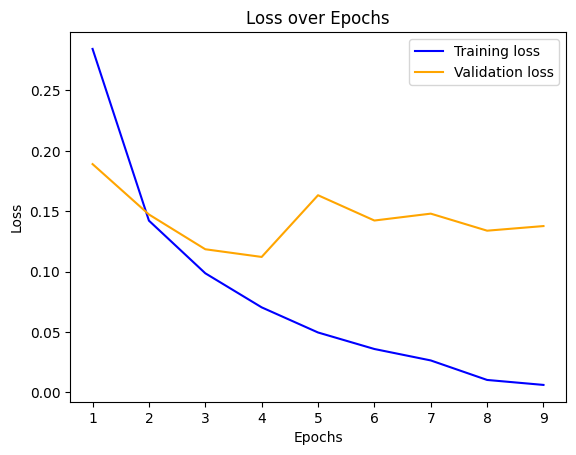

Courbe de précision pour simple_cnn_model (sans augmentation):


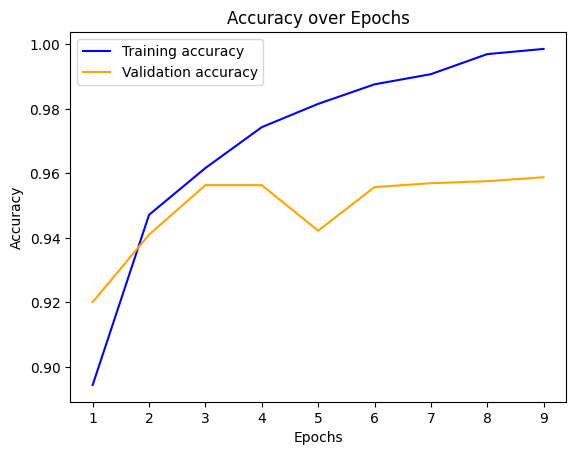

Matrice de confusion pour simple_cnn_model (sans augmentation):
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 149ms/step


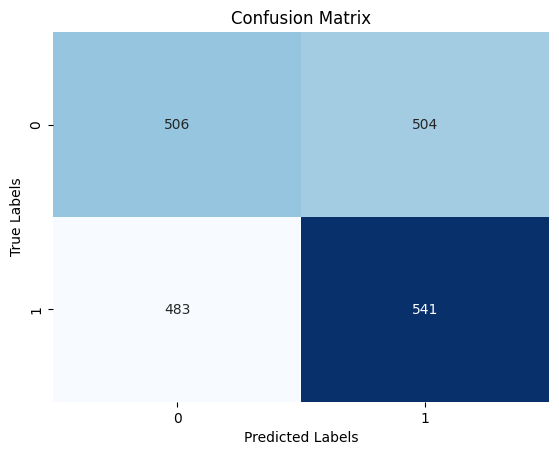

64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 146ms/step
Inference time for simple_cnn_model (sans augmentation): 9.79 seconds


=== Évaluation du modèle sans augmentation: complicated_cnn_model ===
Résumé du modèle (sans augmentation) pour complicated_cnn_model:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │       6,422,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,647,560 (74.95 MB)

 Trainable params: 6,549,186 (24.98 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 13,098,374 (49.97 MB)

Visualisation de la structure pour complicated_cnn_model (sans augmentation):
Courbe de perte pour complicated_cnn_model (sans augmentation):


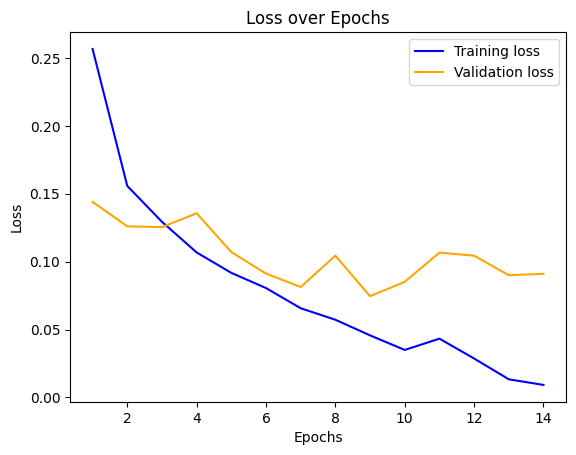

Courbe de précision pour complicated_cnn_model (sans augmentation):


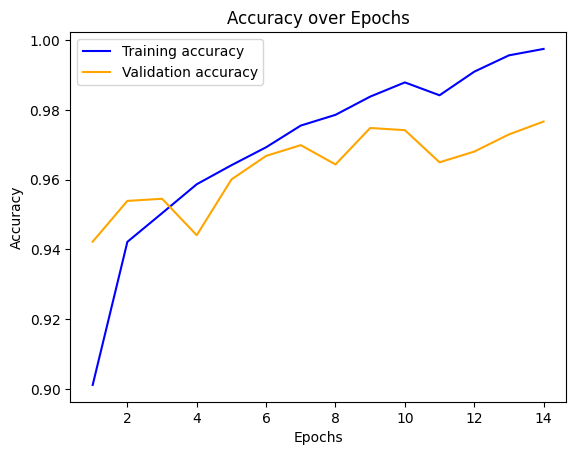

Matrice de confusion pour complicated_cnn_model (sans augmentation):
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 146ms/step


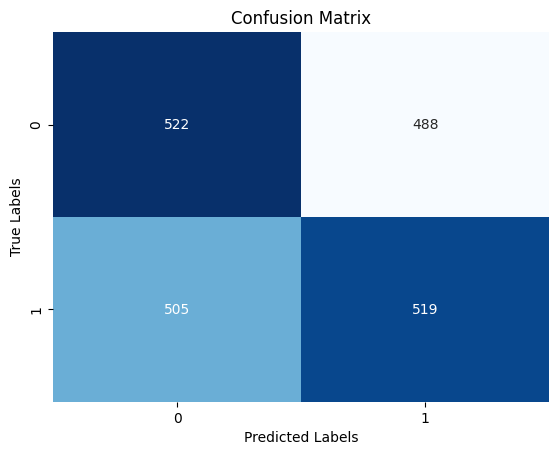

64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 152ms/step
Inference time for complicated_cnn_model (sans augmentation): 10.12 seconds


=== Évaluation du modèle sans augmentation: transfer_vgg_model ===
Résumé du modèle (sans augmentation) pour transfer_vgg_model:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 4, 4, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 256)                 │       2,097,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,106,376 (80.51 MB)

 Trainable params: 2,130,562 (8.13 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 4,261,126 (16.25 MB)

Visualisation de la structure pour transfer_vgg_model (sans augmentation):
Courbe de perte pour transfer_vgg_model (sans augmentation):


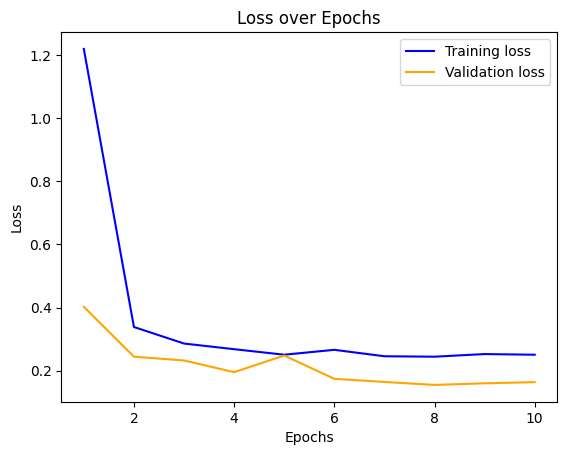

Courbe de précision pour transfer_vgg_model (sans augmentation):


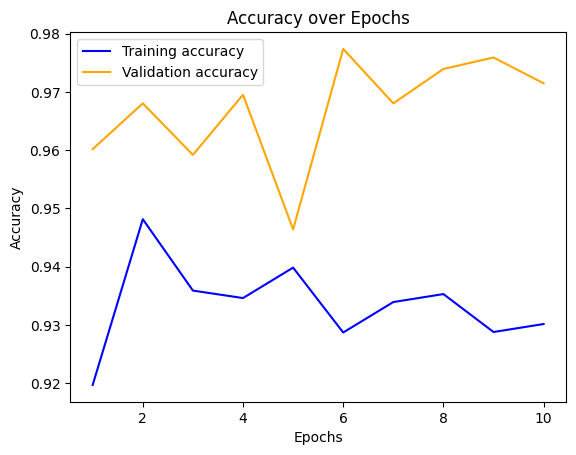

Matrice de confusion pour transfer_vgg_model (sans augmentation):
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step


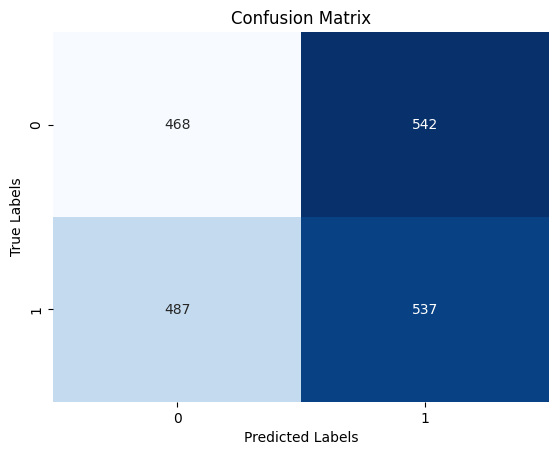

64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 146ms/step
Inference time for transfer_vgg_model (sans augmentation): 9.73 seconds


=== Évaluation du modèle sans augmentation: transfer_densenet_model ===
Résumé du modèle (sans augmentation) pour transfer_densenet_model:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)             │ (None, 4, 4, 1024)          │       7,037,504 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 16384)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 256)                 │       4,194,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,720,648 (75.23 MB)

 Trainable params: 4,227,714 (16.13 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

 Optimizer params: 8,455,430 (32.25 MB)

Visualisation de la structure pour transfer_densenet_model (sans augmentation):
Courbe de perte pour transfer_densenet_model (sans augmentation):


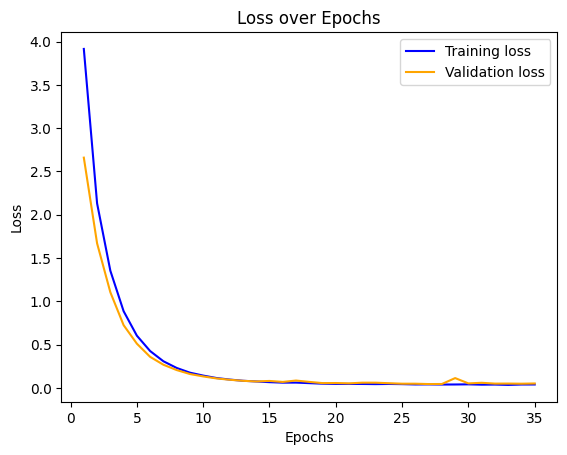

Courbe de précision pour transfer_densenet_model (sans augmentation):


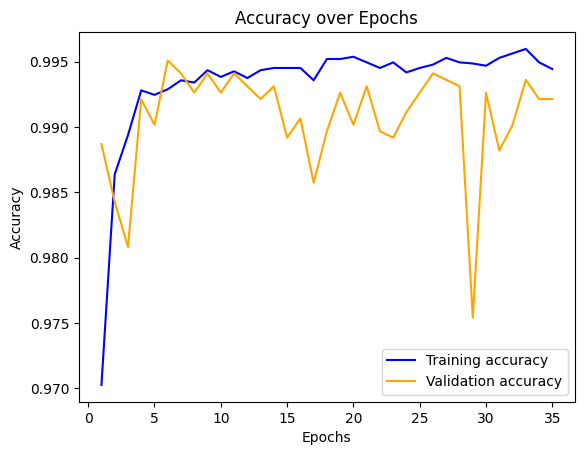

Matrice de confusion pour transfer_densenet_model (sans augmentation):
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 149ms/step


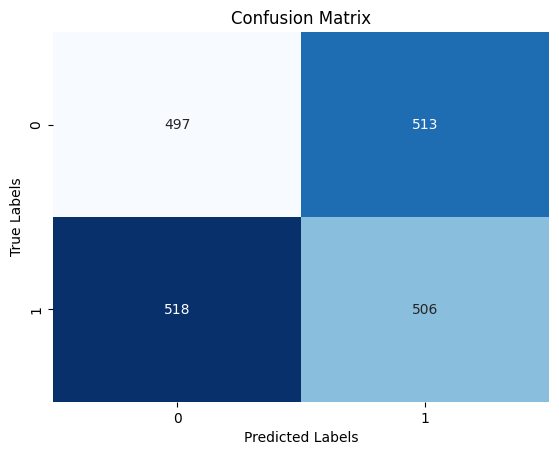

64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 160ms/step
Inference time for transfer_densenet_model (sans augmentation): 10.66 seconds


=== Évaluation du modèle sans augmentation: transfer_mobilenet_model ===
Résumé du modèle (sans augmentation) pour transfer_mobilenet_model:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128 (Functional)    │ (None, 4, 4, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 20480)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 256)                 │       5,243,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,810,566 (48.87 MB)

 Trainable params: 5,276,290 (20.13 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 5,276,292 (20.13 MB)

Visualisation de la structure pour transfer_mobilenet_model (sans augmentation):
Courbe de perte pour transfer_mobilenet_model (sans augmentation):


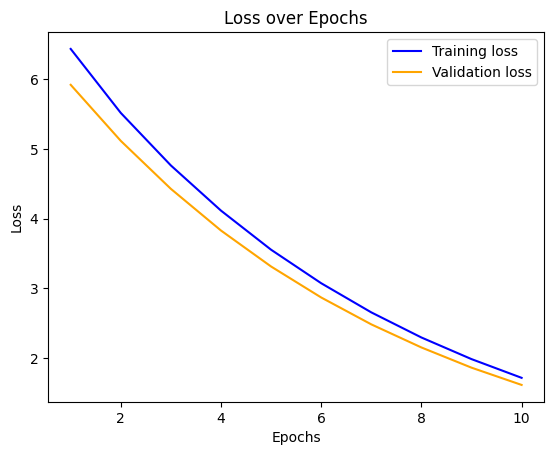

Courbe de précision pour transfer_mobilenet_model (sans augmentation):


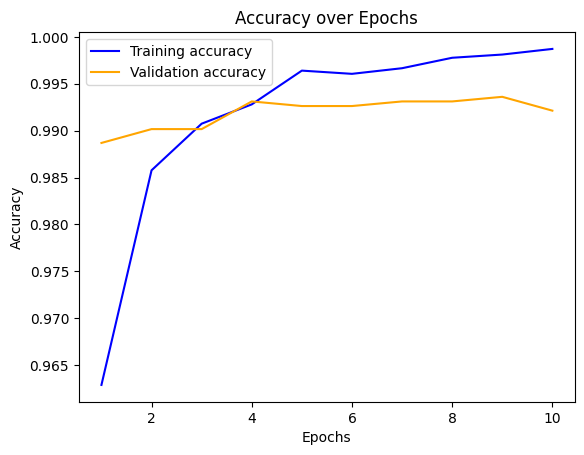

Matrice de confusion pour transfer_mobilenet_model (sans augmentation):
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step


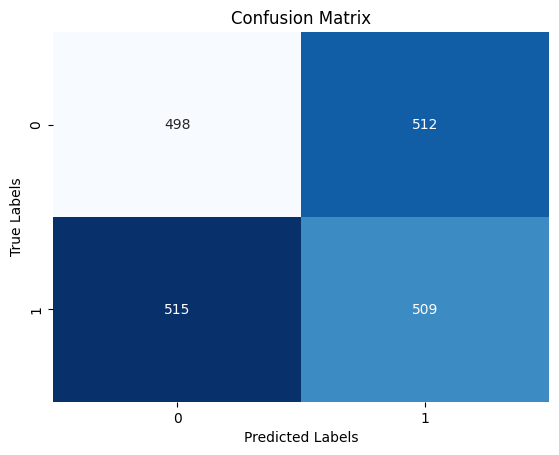

64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 152ms/step
Inference time for transfer_mobilenet_model (sans augmentation): 10.20 seconds




In [ ]:
# Évaluation des modèles sans augmentation
for model_name, model_info in models.items():
    try:
        print(f"=== Évaluation du modèle sans augmentation: {model_name} ===")

        # Récupérer le modèle et son historique
        model = model_info['model']
        history = model_info['history']

        # Afficher le résumé du modèle
        print(f"Résumé du modèle (sans augmentation) pour {model_name}:")
        model.summary()

        # Visualiser la structure du modèle
        print(f"Visualisation de la structure pour {model_name} (sans augmentation):")
        plot_model(model, show_shapes=True, show_layer_names=True)

        # Courbe de perte
        print(f"Courbe de perte pour {model_name} (sans augmentation):")
        plt.figure()
        check_metrics(history, 'loss')

        # Courbe de précision
        print(f"Courbe de précision pour {model_name} (sans augmentation):")
        plt.figure()
        check_metrics(history, 'accuracy')

        # Matrice de confusion
        print(f"Matrice de confusion pour {model_name} (sans augmentation):")
        plt.figure()
        plot_confusion_matrix(model, val_data_subset)

        # Temps d'inférence
        inference_time = measure_epoch_time(model, val_data_subset)
        print(f"Inference time for {model_name} (sans augmentation): {inference_time:.2f} seconds")

        print("\n" + "=" * 50 + "\n")

    except Exception as e:
        print(f"Error occurred during evaluation of {model_name} (sans augmentation): {str(e)}")
        continue


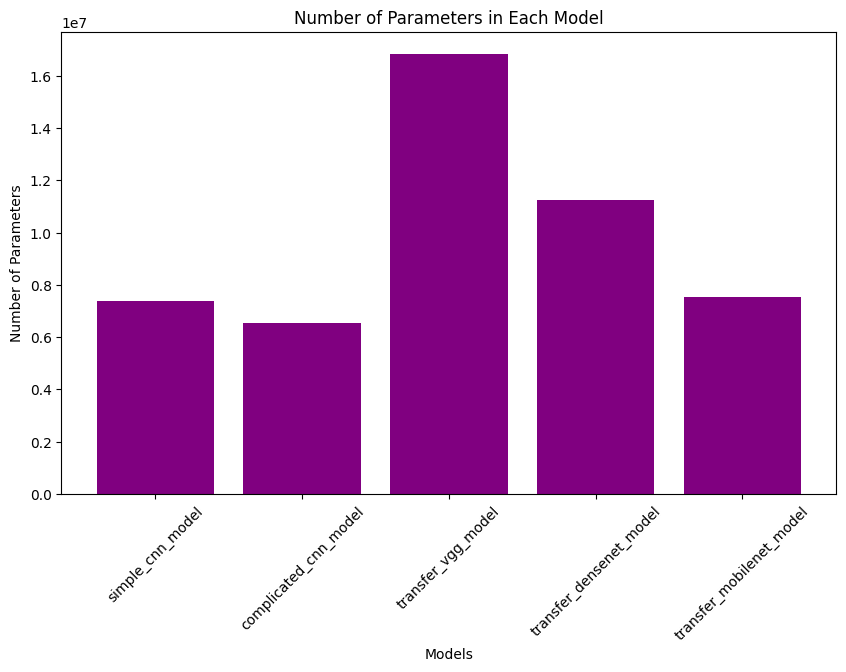

In [ ]:
plot_model_parameters(models)

# Comparer les modèles CNN uniquement

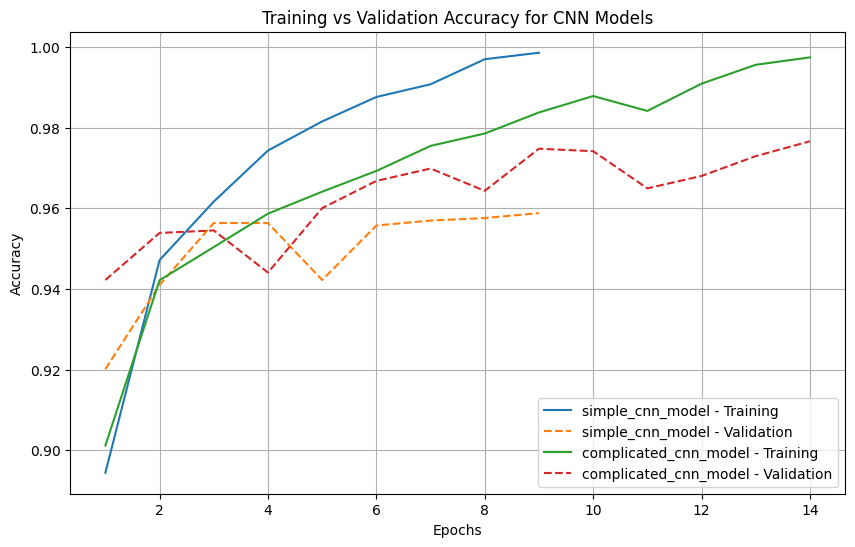

In [ ]:
#Comparer les modèles CNN uniquement
compare_training_and_validation_accuracy_grouped(models, group='cnn')

# Comparer les modèles Transfer Learning uniquement

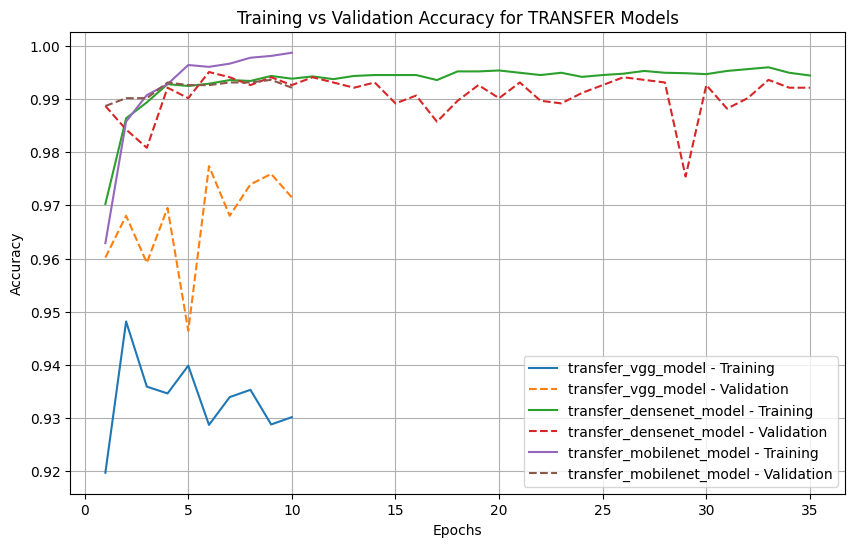

In [ ]:
#Comparer les modèles Transfer Learning uniquement
compare_training_and_validation_accuracy_grouped(models, group='transfer')

# Evaluation des modeles (avec aumentation de données)

##  Paramètres d'augmentation

In [ ]:
# Paramètres d'augmentation
datagen_augmented = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_data_augmented_subset = datagen_augmented.flow_from_directory(
    temp_train_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

val_data_augmented_subset = datagen_augmented.flow_from_directory(
    temp_val_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

# Vérifiez les données réduites avec augmentation
print(f"Training data with augmentation (subset): {train_data_augmented_subset.samples} samples")
print(f"Validation data with augmentation (subset): {val_data_augmented_subset.samples} samples")


Found 16277 images belonging to 2 classes.
Found 2034 images belonging to 2 classes.
Training data with augmentation (subset): 16277 samples
Validation data with augmentation (subset): 2034 samples


#  Entraînement des modèles avec augmentation de données

In [ ]:
# Chemin pour sauvegarder les modèles avec augmentation de données
save_dir_augmented = '/content/drive/MyDrive/APA/saved_models/with_data_augmentation'
if not os.path.exists(save_dir_augmented):
    os.makedirs(save_dir_augmented)

# Entraînement des modèles
for model_name, model_info in models_augmented.items():
    try:
        model = model_info['model']
        callbacks = model_info.get('callbacks', [])

        # Définir les chemins pour sauvegarder le modèle et l'historique
        model_filename = os.path.join(save_dir_augmented, f'{model_name}_model.keras')
        history_filename = os.path.join(save_dir_augmented, f'{model_name}_history.pkl')

        # Vérifier si le modèle et l'historique existent déjà
        if os.path.exists(model_filename) and os.path.exists(history_filename):
            print(f"Model {model_name} already trained and saved. Skipping training...")
            continue

        print(f"Training model {model_name} with data augmentation...")

        model.optimizer = tf.keras.optimizers.Adam()

        # Entraîner le modèle avec les données augmentées
        history = model.fit(
            train_data_augmented_subset,
            validation_data=val_data_augmented_subset,
            epochs=epochs,
            callbacks=[early_stopping, reduce_lr],
            verbose=1
        )

        # Sauvegarder le modèle et l'historique
        model.save(model_filename)
        with open(history_filename, 'wb') as history_file:
            pickle.dump(history.history, history_file)

        # Mettre à jour les informations dans le dictionnaire
        models_augmented[model_name]['history'] = history.history

        print(f"Model {model_name} trained and saved.")
    except Exception as e:
        print(f"Error occurred while training {model_name}: {str(e)}")
        continue

print("All models with augmentation have been trained and saved.")


Model simple_cnn_model already trained and saved. Skipping training...
Model complicated_cnn_model already trained and saved. Skipping training...
Model transfer_vgg_model already trained and saved. Skipping training...
Model transfer_densenet_model already trained and saved. Skipping training...
Model transfer_mobilenet_model already trained and saved. Skipping training...
All models with augmentation have been trained and saved.


##Test des modèles avec augmentation des données

In [ ]:
# Chemin pour les modèles sauvegardés
save_dir = '/content/drive/MyDrive/APA/saved_models/with_data_augmentation'

# Chargement des modèles et évaluation sur les données de test
print("=== Évaluation des modèles sur l'ensemble de test ===")
for file in os.listdir(save_dir):
    if file.endswith('_model.keras'):
        model_name = file.replace('_model.keras', '')
        model_path = os.path.join(save_dir, file)

        print(f"\nÉvaluation du modèle : {model_name}")
        try:
            # Charger le modèle
            model = tf.keras.models.load_model(model_path)

            # Évaluer le modèle sur l'ensemble de test
            test_loss, test_accuracy = model.evaluate(test_data_subset, verbose=1)

            # Afficher les résultats
            print(f" - Test Loss : {test_loss:.4f}")
            print(f" - Test Accuracy : {test_accuracy:.4f}")
        except Exception as e:
            print(f"Erreur lors de l'évaluation du modèle {model_name} : {e}")

print("\nÉvaluation terminée pour tous les modèles.")


=== Évaluation des modèles sur l'ensemble de test ===

Évaluation du modèle : complicated_cnn_model
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 181ms/step - accuracy: 0.8927 - loss: 0.3067
 - Test Loss : 0.2487
 - Test Accuracy : 0.9037

Évaluation du modèle : transfer_mobilenet_model


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:713: UserWarning: Skipping variable loading for optimizer 'SGD', because it has 8 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 197ms/step - accuracy: 0.9886 - loss: 0.7075
 - Test Loss : 0.7104
 - Test Accuracy : 0.9843

Évaluation du modèle : transfer_densenet_model
64/64 ━━━━━━━━━━━━━━━━━━━━ 29s 252ms/step - accuracy: 0.9904 - loss: 0.0535
 - Test Loss : 0.0499
 - Test Accuracy : 0.9912

Évaluation du modèle : simple_cnn_model


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:713: UserWarning: Skipping variable loading for optimizer 'adam', because it has 18 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 175ms/step - accuracy: 0.9877 - loss: 0.0483
 - Test Loss : 0.0669
 - Test Accuracy : 0.9774

Évaluation du modèle : transfer_vgg_model
64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 192ms/step - accuracy: 0.9766 - loss: 0.1263
 - Test Loss : 0.1491
 - Test Accuracy : 0.9705

Évaluation terminée pour tous les modèles.


# Résultats des modèles avec augmentation des données

| Modèle                     | Test Loss | Test Accuracy |
|----------------------------|-----------|---------------|
| `complicated_cnn_model`    | 0.2487    | 0.9037        |
| `transfer_mobilenet_model` | 0.7104    | 0.9843        |
| `transfer_densenet_model`  | 0.0499    | 0.9912        |
| `simple_cnn_model`         | 0.0669    | 0.9774        |
| `transfer_vgg_model`       | 0.1491    | 0.9705        |

## Analyse :
- **Meilleurs modèles** :
  - `transfer_densenet_model` : Meilleure précision (99.12 %) avec une très faible perte.
  - `transfer_mobilenet_model` : Excellente précision (98.43 %), mais une perte légèrement élevée.
  
- **Performances solides** :
  - `simple_cnn_model` : Bonne précision (97.74 %) et faible perte.
  - `transfer_vgg_model` : Bonne précision (97.05 %), mais perte modérée.
  
- **Performance la plus basse** :
  - `complicated_cnn_model` : Test Accuracy plus faible (90.37 %), mais reste acceptable.

Ces résultats montrent une nette amélioration grâce à l'augmentation des données, surtout pour les modèles basés sur **Transfer Learning**.


#  Évaluation des modèles avec augmentation

=== Évaluation du modèle avec augmentation: complicated_cnn_model ===
Résumé du modèle (avec augmentation) pour complicated_cnn_model:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_6 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 256)                 │       6,422,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,647,560 (74.95 MB)

 Trainable params: 6,549,186 (24.98 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 13,098,374 (49.97 MB)

Visualisation de la structure pour complicated_cnn_model (avec augmentation):
Courbe de perte pour complicated_cnn_model (avec augmentation):


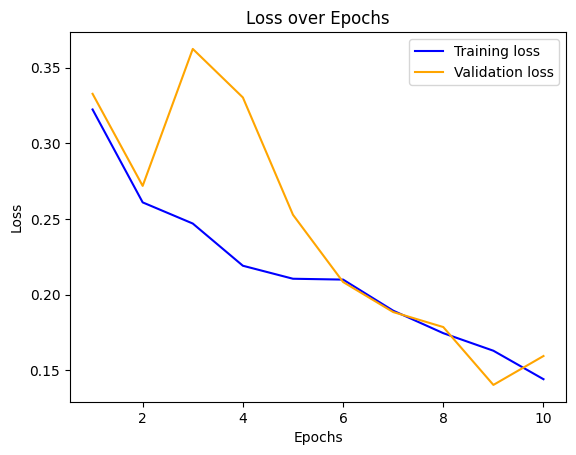

Courbe de précision pour complicated_cnn_model (avec augmentation):


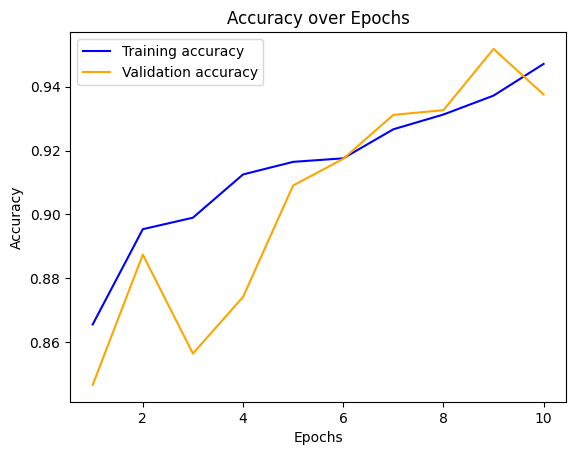

Matrice de confusion pour complicated_cnn_model (avec augmentation):


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


64/64 ━━━━━━━━━━━━━━━━━━━━ 19s 285ms/step


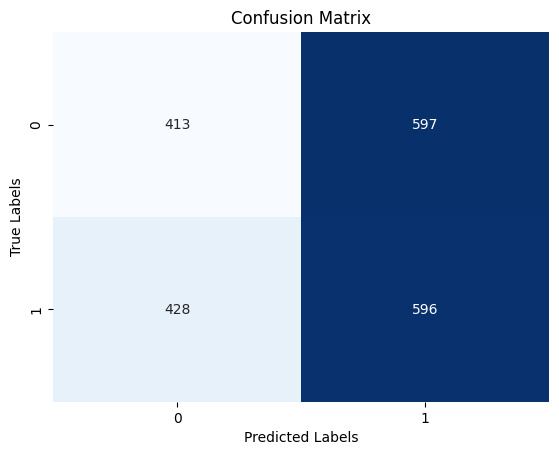

64/64 ━━━━━━━━━━━━━━━━━━━━ 19s 301ms/step
Inference time for complicated_cnn_model (avec augmentation): 19.86 seconds


=== Évaluation du modèle avec augmentation: transfer_mobilenet_model ===
Résumé du modèle (avec augmentation) pour transfer_mobilenet_model:


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128 (Functional)    │ (None, 4, 4, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_11 (Flatten)                 │ (None, 20480)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_33 (Dense)                     │ (None, 256)                 │       5,243,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_22 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_34 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_23 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_35 (Dense)                     │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,810,566 (48.87 MB)

 Trainable params: 5,276,290 (20.13 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 5,276,292 (20.13 MB)

Visualisation de la structure pour transfer_mobilenet_model (avec augmentation):
Courbe de perte pour transfer_mobilenet_model (avec augmentation):


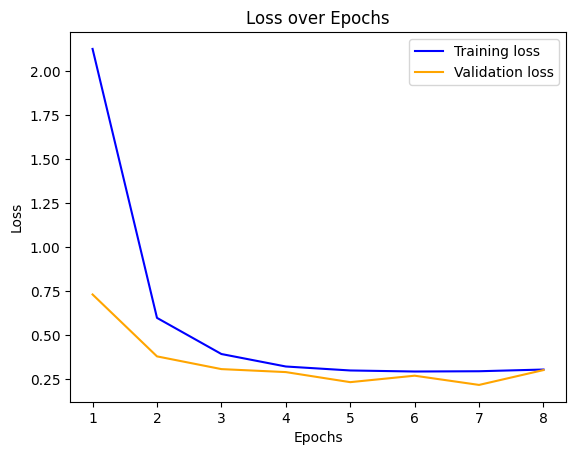

Courbe de précision pour transfer_mobilenet_model (avec augmentation):


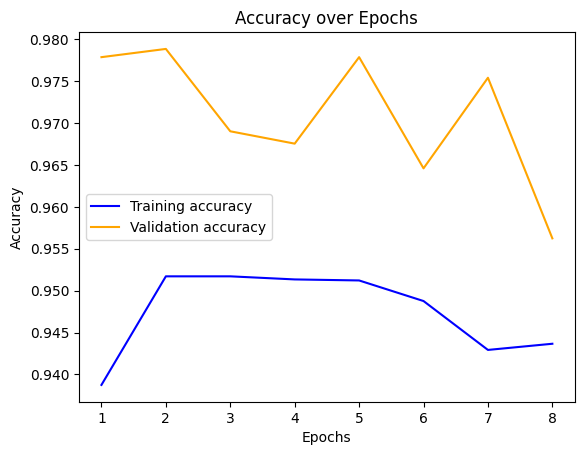

Matrice de confusion pour transfer_mobilenet_model (avec augmentation):
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 317ms/step


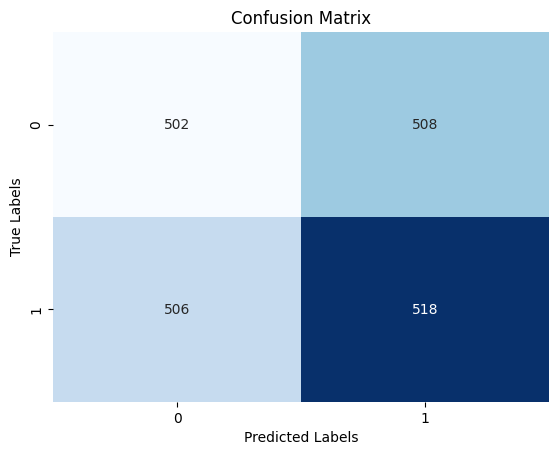

64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 304ms/step
Inference time for transfer_mobilenet_model (avec augmentation): 20.29 seconds


=== Évaluation du modèle avec augmentation: transfer_densenet_model ===
Résumé du modèle (avec augmentation) pour transfer_densenet_model:


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)             │ (None, 4, 4, 1024)          │       7,037,504 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_10 (Flatten)                 │ (None, 16384)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 256)                 │       4,194,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_20 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_31 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_21 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_32 (Dense)                     │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,720,648 (75.23 MB)

 Trainable params: 4,227,714 (16.13 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

 Optimizer params: 8,455,430 (32.25 MB)

Visualisation de la structure pour transfer_densenet_model (avec augmentation):
Courbe de perte pour transfer_densenet_model (avec augmentation):


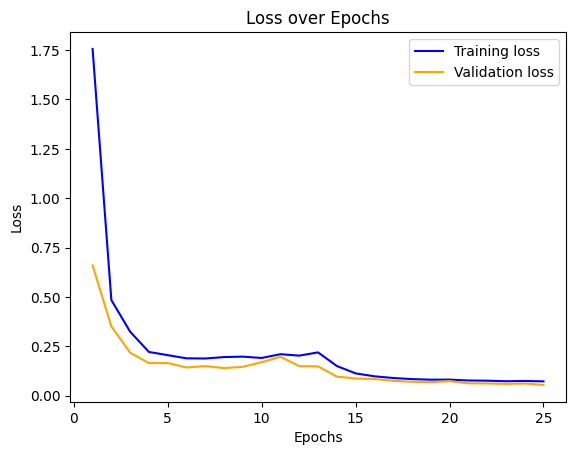

Courbe de précision pour transfer_densenet_model (avec augmentation):


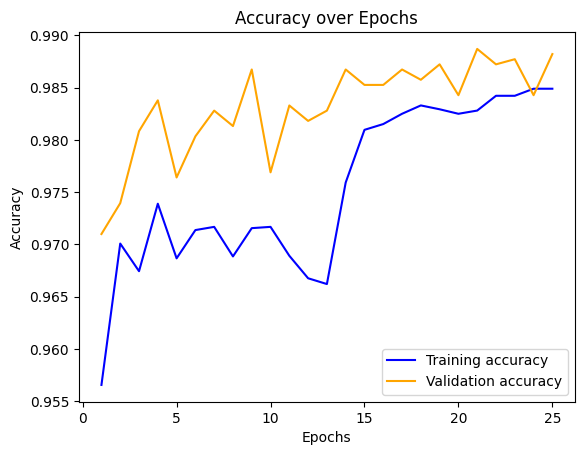

Matrice de confusion pour transfer_densenet_model (avec augmentation):
64/64 ━━━━━━━━━━━━━━━━━━━━ 35s 439ms/step


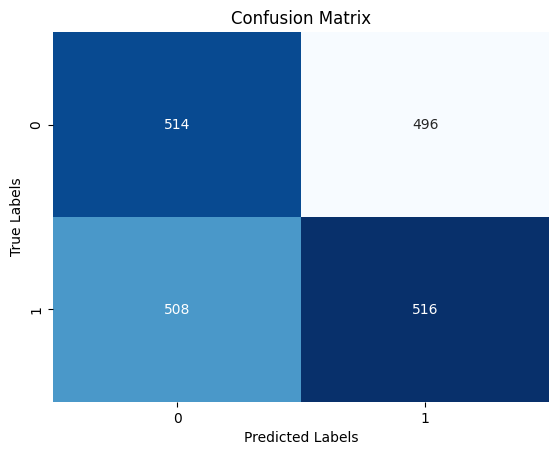

64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 314ms/step
Inference time for transfer_densenet_model (avec augmentation): 20.73 seconds


=== Évaluation du modèle avec augmentation: simple_cnn_model ===
Résumé du modèle (avec augmentation) pour simple_cnn_model:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_5 (Flatten)                  │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 128)                 │       7,372,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,177,736 (84.60 MB)

 Trainable params: 7,392,578 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 14,785,158 (56.40 MB)

Visualisation de la structure pour simple_cnn_model (avec augmentation):
Courbe de perte pour simple_cnn_model (avec augmentation):


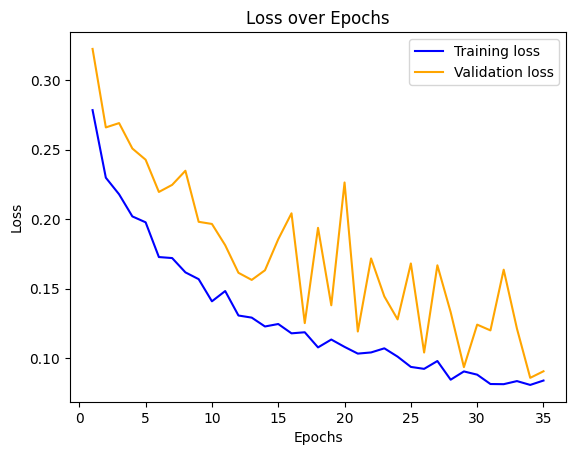

Courbe de précision pour simple_cnn_model (avec augmentation):


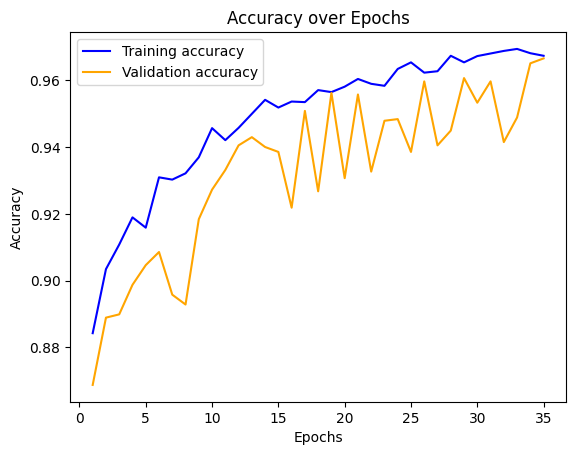

Matrice de confusion pour simple_cnn_model (avec augmentation):
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 280ms/step


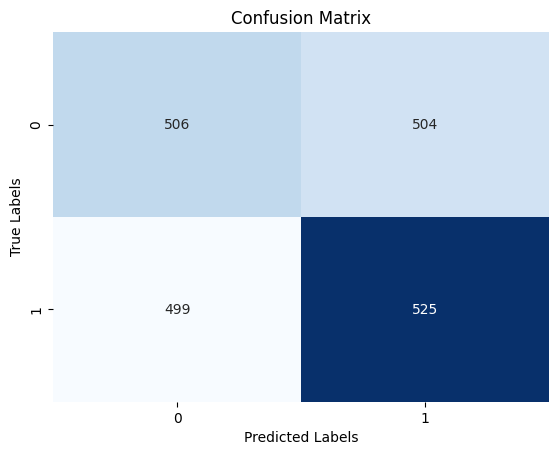

64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 289ms/step
Inference time for simple_cnn_model (avec augmentation): 19.11 seconds


=== Évaluation du modèle avec augmentation: transfer_vgg_model ===
Résumé du modèle (avec augmentation) pour transfer_vgg_model:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 4, 4, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 256)                 │       2,097,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,106,376 (80.51 MB)

 Trainable params: 2,130,562 (8.13 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 4,261,126 (16.25 MB)

Visualisation de la structure pour transfer_vgg_model (avec augmentation):
Courbe de perte pour transfer_vgg_model (avec augmentation):


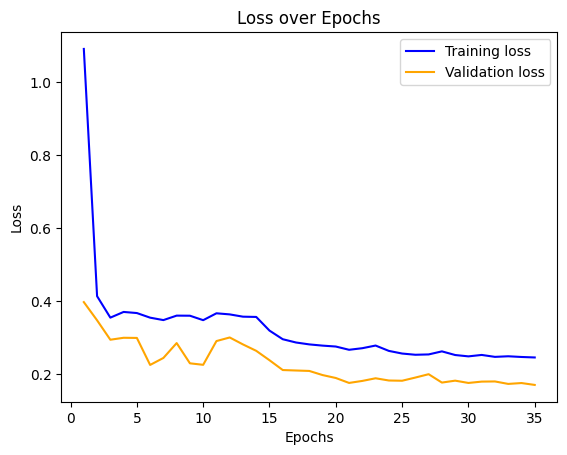

Courbe de précision pour transfer_vgg_model (avec augmentation):


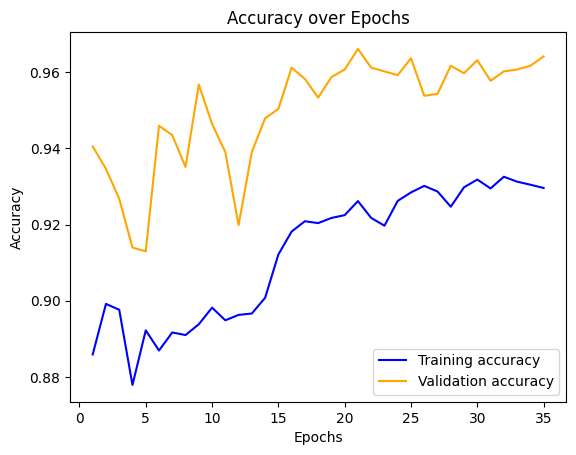

Matrice de confusion pour transfer_vgg_model (avec augmentation):
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 294ms/step


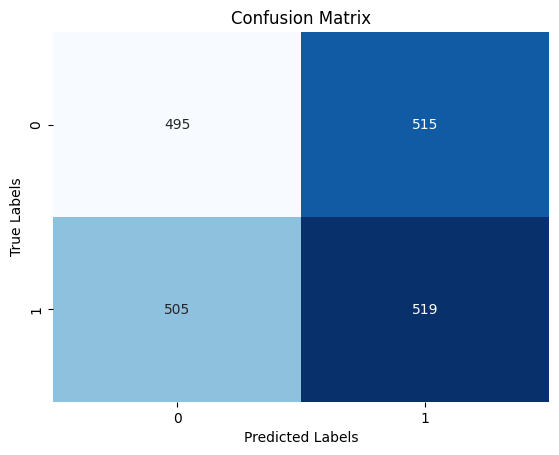

64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 284ms/step
Inference time for transfer_vgg_model (avec augmentation): 18.84 seconds




In [ ]:
# Évaluation des modèles avec augmentation
for model_name, model_info in models_augmented.items():
    try:
        print(f"=== Évaluation du modèle avec augmentation: {model_name} ===")

        # Récupérer le modèle et son historique
        model = model_info['model']
        history = model_info['history']

        # Afficher le résumé du modèle
        print(f"Résumé du modèle (avec augmentation) pour {model_name}:")
        model.summary()

        # Visualiser la structure du modèle
        print(f"Visualisation de la structure pour {model_name} (avec augmentation):")
        plot_model(model, show_shapes=True, show_layer_names=True)

        # Courbe de perte
        print(f"Courbe de perte pour {model_name} (avec augmentation):")
        plt.figure()
        check_metrics(history, 'loss')

        # Courbe de précision
        print(f"Courbe de précision pour {model_name} (avec augmentation):")
        plt.figure()
        check_metrics(history, 'accuracy')

        # Matrice de confusion
        print(f"Matrice de confusion pour {model_name} (avec augmentation):")
        plt.figure()
        plot_confusion_matrix(model, val_data_augmented_subset)

        # Temps d'inférence
        inference_time = measure_epoch_time(model, val_data_augmented_subset)
        print(f"Inference time for {model_name} (avec augmentation): {inference_time:.2f} seconds")

        print("\n" + "=" * 50 + "\n")

    except Exception as e:
        print(f"Error occurred during evaluation of {model_name} (avec augmentation): {str(e)}")
        continue


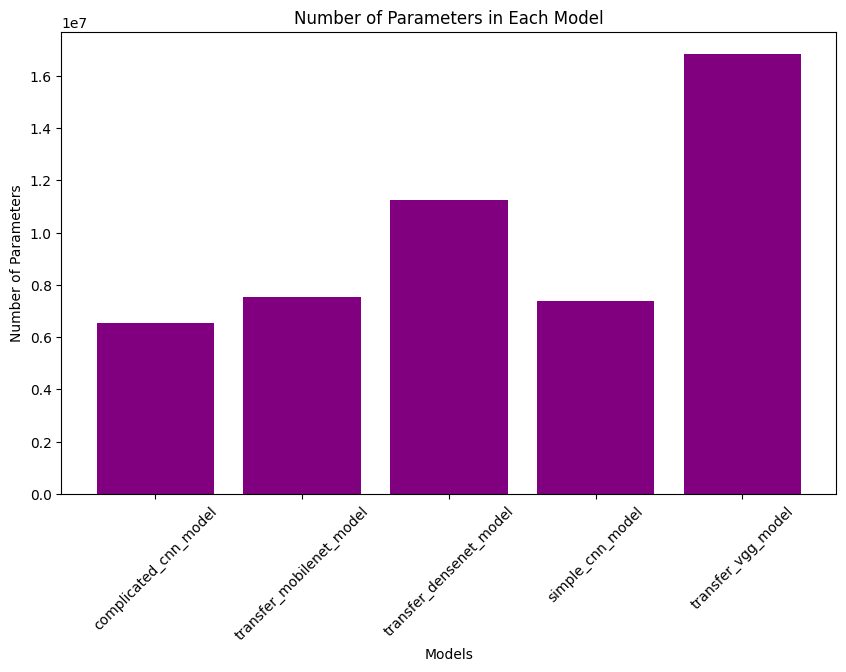

In [ ]:
plot_model_parameters(models_augmented)

#Comparer les modèles CNN uniquement

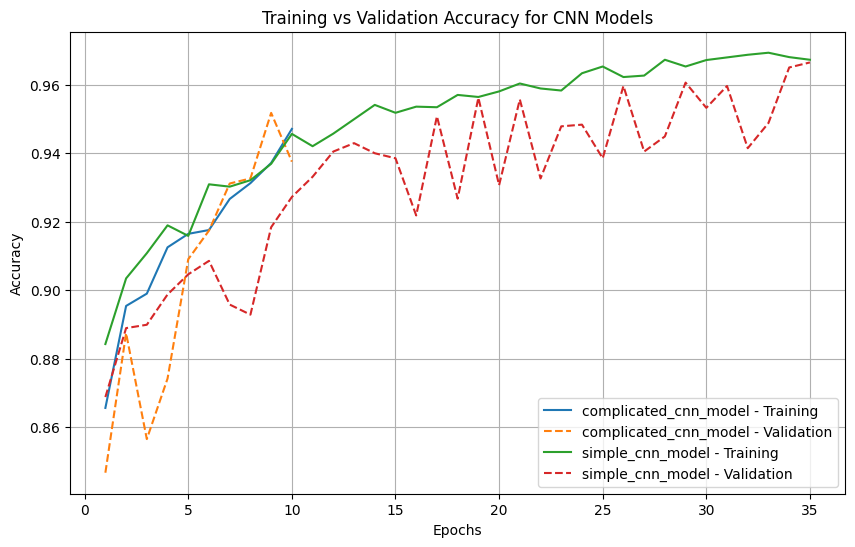

In [ ]:
#Comparer les modèles CNN uniquement
compare_training_and_validation_accuracy_grouped(models_augmented, group='cnn')

#Comparer les modèles Transfer Learning uniquement

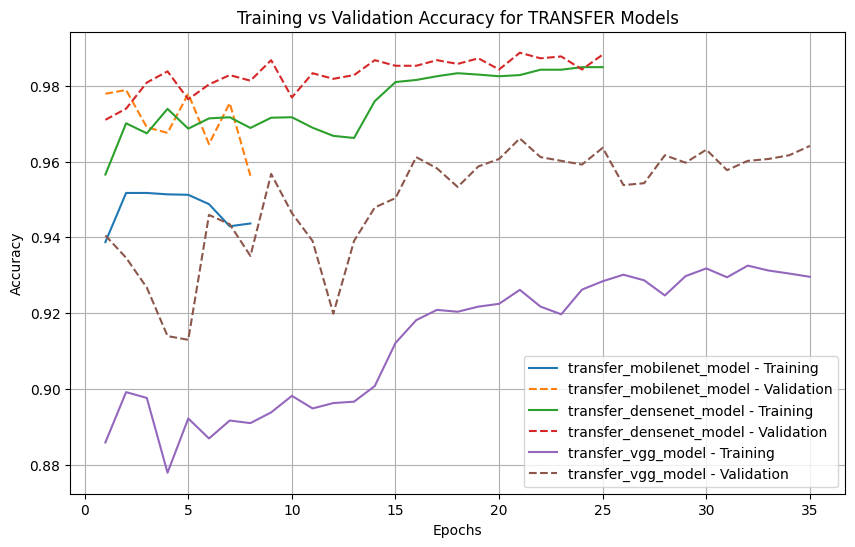

In [ ]:
#Comparer les modèles Transfer Learning uniquement
compare_training_and_validation_accuracy_grouped(models_augmented, group='transfer')

#  Comparer les métriques

64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 150ms/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 145ms/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 15s 180ms/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 267ms/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 158ms/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 263ms/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 305ms/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 404ms/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 272ms/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 21s 313ms/step


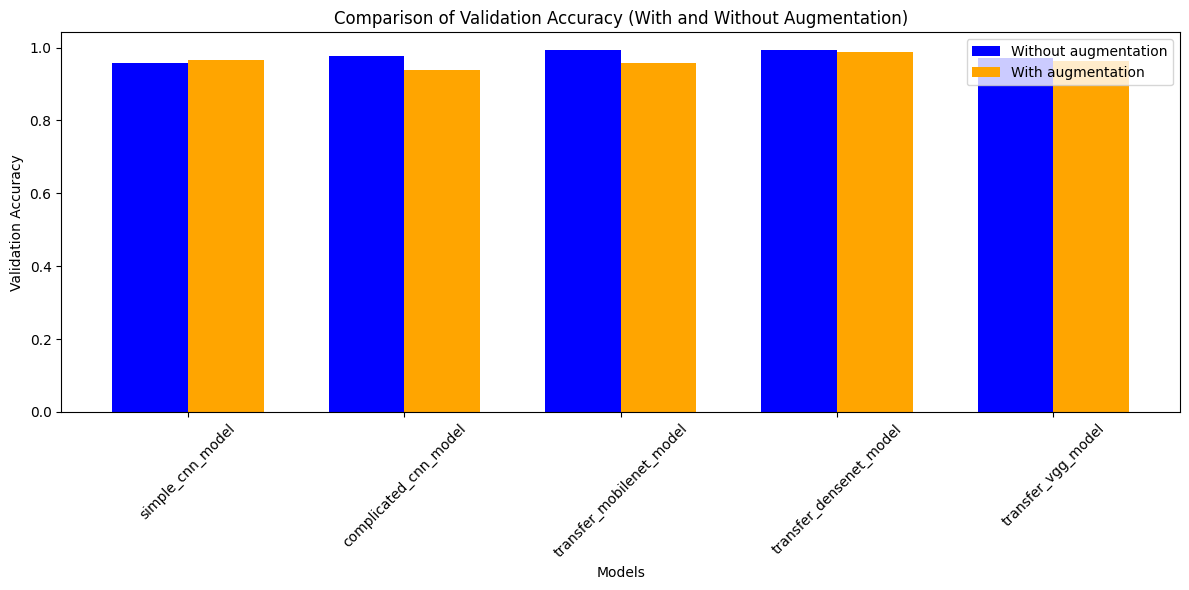

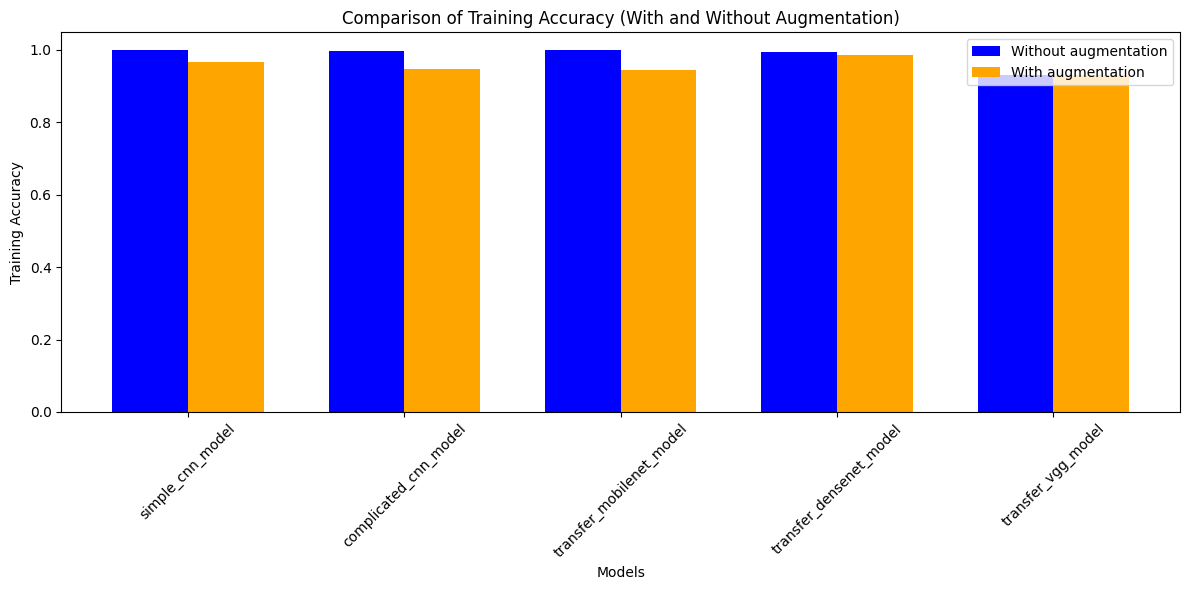

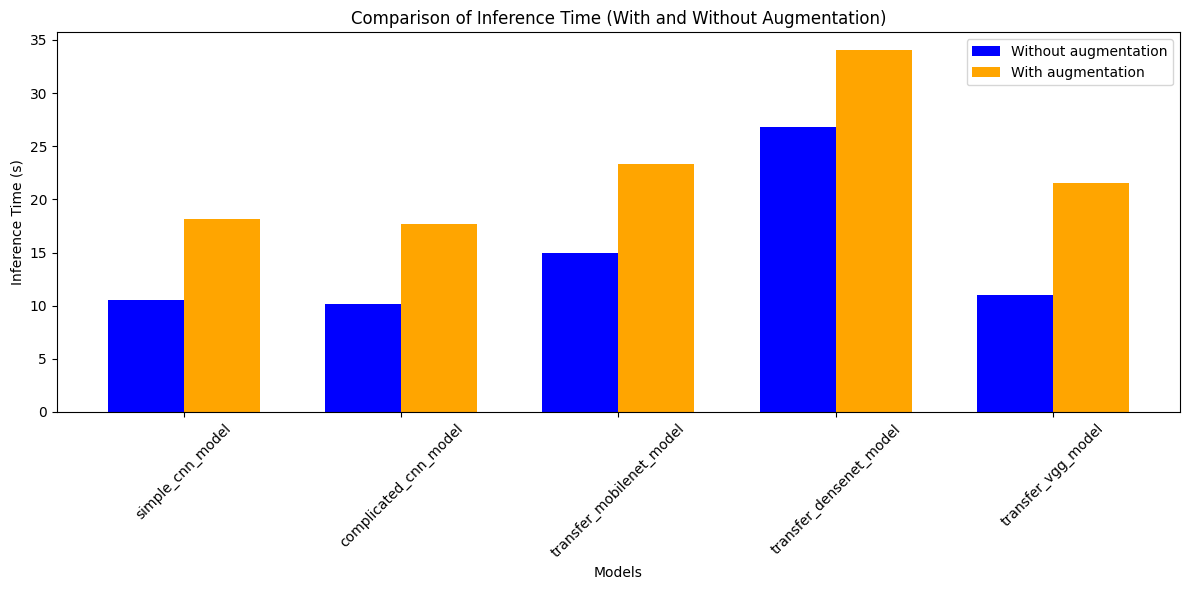

In [ ]:
# Initialisation des dictionnaires pour les résultats
results = {'without_augmentation': {}, 'with_augmentation': {}}

# Dictionnaires contenant les modèles et historiques
datasets = {
    'without_augmentation': models,
    'with_augmentation': models_augmented
}

# Comparer les métriques
for augmentation_type, model_dict in datasets.items():
    for model_name, model_info in model_dict.items():
        model = model_info['model']
        history = model_info['history']

        # Récupérer la précision finale sur validation
        final_val_acc = history['val_accuracy'][-1]
        final_train_acc = history['accuracy'][-1]

        # Mesurer le temps d'inférence moyen
        inference_time = measure_epoch_time(
            model, val_data_augmented_subset if augmentation_type == 'with_augmentation' else val_data_subset
        )

        # Stocker les résultats
        results[augmentation_type][model_name] = {
            'final_val_accuracy': final_val_acc,
            'final_train_accuracy': final_train_acc,
            'inference_time': inference_time
        }

# Données pour l'affichage
models_list = list(results['without_augmentation'].keys())



# Données avec augmentation
val_acc_with_aug = [results['with_augmentation'][model]['final_val_accuracy'] for model in models_list]
train_acc_with_aug = [results['with_augmentation'][model]['final_train_accuracy'] for model in models_list]

# Données sans augmentation
val_acc_without_aug = [results['without_augmentation'][model]['final_val_accuracy'] for model in models_list]
train_acc_without_aug = [results['without_augmentation'][model]['final_train_accuracy'] for model in models_list]

# Configuration pour les barres côte à côte
x = np.arange(len(models_list))
width = 0.35

# Graphique pour la précision de validation
plt.figure(figsize=(12, 6))
plt.bar(x - width/2, val_acc_without_aug, width, label='Without augmentation', color='blue')
plt.bar(x + width/2, val_acc_with_aug, width, label='With augmentation', color='orange')
plt.xticks(x, models_list, rotation=45)
plt.xlabel('Models')
plt.ylabel('Validation Accuracy')
plt.title('Comparison of Validation Accuracy (With and Without Augmentation)')
plt.legend()
plt.tight_layout()
plt.show()

# Graphique pour la précision d'entraînement
plt.figure(figsize=(12, 6))
plt.bar(x - width/2, train_acc_without_aug, width, label='Without augmentation', color='blue')
plt.bar(x + width/2, train_acc_with_aug, width, label='With augmentation', color='orange')
plt.xticks(x, models_list, rotation=45)
plt.xlabel('Models')
plt.ylabel('Training Accuracy')
plt.title('Comparison of Training Accuracy (With and Without Augmentation)')
plt.legend()
plt.tight_layout()
plt.show()

# Temps d'inférence
inference_time_without_aug = [results['without_augmentation'][model]['inference_time'] for model in models_list]
inference_time_with_aug = [results['with_augmentation'][model]['inference_time'] for model in models_list]

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, inference_time_without_aug, width, label='Without augmentation', color='blue')
plt.bar(x + width/2, inference_time_with_aug, width, label='With augmentation', color='orange')
plt.xticks(x, models_list, rotation=45)
plt.xlabel('Models')
plt.ylabel('Inference Time (s)')
plt.title('Comparison of Inference Time (With and Without Augmentation)')
plt.legend()
plt.tight_layout()
plt.show()


# État de l'art

## **Introduction**
Dans le cadre de ce projet, l’objectif est d’explorer les modèles avancés de vision par ordinateur, tels que les réseaux de neurones convolutifs (CNN) et les modèles basés sur le transfert d’apprentissage, en les adaptant à un jeu de données sélectionné. L’approche suivie s’appuie sur des architectures populaires comme DenseNet et MobileNet, reconnues pour leur performance et leur efficacité computationnelle, tout en tenant compte des améliorations récentes à l’état de l’art. De plus, des réseaux convolutifs classiques comme VGG16 et ResNet, étudiés au cours, servent de base pour l'intégration des méthodes modernes.

---

## **1. Modèles avancés vus en cours**
Les réseaux de neurones convolutifs (CNN), introduits comme outils fondamentaux pour les tâches de vision par ordinateur, forment le cœur des modèles utilisés dans ce projet. Parmi les modèles vus en cours, les architectures classiques telles que VGG16 et ResNet ont servi de référence initiale. Ces modèles, connus pour leurs performances solides, ont été enrichis et comparés à des architectures modernes comme DenseNet et MobileNet, qui répondent mieux aux contraintes actuelles en matière d’efficacité et de précision.

---

## **2. Améliorations à l'état de l'art**
Pour répondre aux consignes demandant d’améliorer les modèles en suivant les dernières méthodes, plusieurs stratégies ont été mises en œuvre :

### **2.1. Transfert d’apprentissage avancé**
Les modèles comme DenseNet et MobileNet ont été choisis pour leur capacité à maintenir des performances élevées tout en réduisant le nombre de paramètres et en optimisant l’efficacité computationnelle.

- **DenseNet** : Introduit un mécanisme où chaque couche est connectée à toutes les couches précédentes, réduisant ainsi la redondance des caractéristiques. DenseNet a été utilisé dans ce projet avec une base gelée, complétée par des couches personnalisées pour la tâche.
- **MobileNet** : Ce modèle, conçu pour des environnements à faibles ressources, utilise des convolutions en profondeur séparables, permettant une réduction significative des calculs tout en conservant de bonnes performances.

Ces modèles, combinés à des techniques d’optimisation comme `ReduceLROnPlateau` et l’utilisation de stratégies d’augmentation des données, permettent d’atteindre un compromis idéal entre performance et efficacité.

---

### **2.2. Vision Transformers et approches hybrides**
Les Transformers, comme le Vision Transformer (ViT), introduisent une approche différente en remplaçant les convolutions par des mécanismes d’attention globale. Cependant, en raison de leur complexité computationnelle, leur intégration est souvent limitée à des ensembles de données très volumineux.

Pour répondre aux contraintes pratiques de ce projet, des architectures hybrides combinant CNN et Transformers, comme ConViT ou Swin Transformer, pourraient représenter une piste d'amélioration future.

---

### **2.3. Augmentation des données**
L’augmentation des données est une méthode essentielle pour améliorer la robustesse et la généralisation des modèles. Les techniques utilisées incluent :
- **Flip horizontal et vertical** : Pour simuler différentes orientations des images.
- **Crop et rotation aléatoires** : Pour diversifier les perspectives.
- **CutMix** : Mélange de pixels de plusieurs images.
- **RandAugment** : Automatisation des stratégies d’augmentation.

Ces approches permettent de pallier les limitations liées à la taille du jeu de données tout en augmentant sa diversité.

---

## **3. Méthodologie suivie**
Le projet s’est concentré sur l’entraînement de plusieurs modèles, avec et sans augmentation des données. Les résultats démontrent que les architectures modernes, lorsqu’elles sont combinées à des approches avancées d’optimisation et d’augmentation, surpassent les modèles classiques dans des scénarios spécifiques.

Les modèles suivants ont été entraînés :
1. **Simple CNN** : Baseline simple pour comparaison.
2. **Complicated CNN** : Extension du modèle simple avec des couches supplémentaires et de la régularisation.
3. **DenseNet** et **MobileNet** : Modèles modernes de transfert d’apprentissage.
4. **VGG16** : Version classique avec une base gelée.

---

## **4. Résultats obtenus**
Les résultats obtenus, avec et sans augmentation des données, confirment la pertinence des approches modernes. Les modèles avancés comme DenseNet surpassent les autres modèles en termes de précision et de robustesse.

| Modèle                     | Test Loss (Sans Augmentation) | Test Accuracy (Sans Augmentation) | Test Loss (Avec Augmentation) | Test Accuracy (Avec Augmentation) |
|----------------------------|-------------------------------|------------------------------------|-------------------------------|------------------------------------|
| **Simple CNN**             | 0.1638                       | 94.79%                            | 0.0669                       | 97.74%                            |
| **Complicated CNN**        | 0.1162                       | 95.92%                            | 0.2487                       | 90.37%                            |
| **VGG16**                  | 0.4130                       | 95.43%                            | 0.1491                       | 97.05%                            |
| **DenseNet**               | 0.0451                       | 99.36%                            | 0.0499                       | 99.12%                            |
| **MobileNet**              | 5.9241                       | 98.53%                            | 0.7104                       | 98.43%                            |

---

## **5. Conclusion et perspectives**
En intégrant des modèles avancés comme DenseNet et MobileNet, combinés aux techniques modernes d’augmentation des données, ce projet démontre que les approches actuelles permettent d’améliorer considérablement les performances sur des tâches de classification. Les pistes futures incluent l’exploration des architectures hybrides CNN-Transformers et l’entraînement de Vision Transformers pour des jeux de données plus volumineux.
